In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_reward(p):
    """Симуляция одного рывка ручки: +1 с вер. p, -1 с вер. 1-p"""
    return 1 if np.random.rand() < p else -1


In [10]:

def run_strategy_1_random(p1, p2, steps=10000):
    """Стратегия 1: Случайный выбор"""
    total_reward = 0
    probabilities = [p1, p2]
    
    for _ in range(steps):
        # Выбираем ручку случайно (0 или 1)
        arm = np.random.randint(0, 2)
        total_reward += get_reward(probabilities[arm])
        
    return total_reward / steps


In [11]:

def run_strategy_2_wsls(p1, p2, steps=10000):
    """Стратегия 2: Win-Stay, Lose-Switch"""
    total_reward = 0
    probabilities = [p1, p2]
    
    current_arm = 0 # Начинаем с первой ручки (можно случайно)
    
    for _ in range(steps):
        # Дергаем текущую ручку
        outcome = get_reward(probabilities[current_arm])
        total_reward += outcome
        
        # Логика смены ручки
        if outcome == 1:
            pass # Win-Stay: остаемся на той же ручке
        else:
            current_arm = 1 - current_arm # Lose-Switch: меняем ручку (0->1 или 1->0)
            
    return total_reward / steps


Идет расчет... (может занять пару секунд)


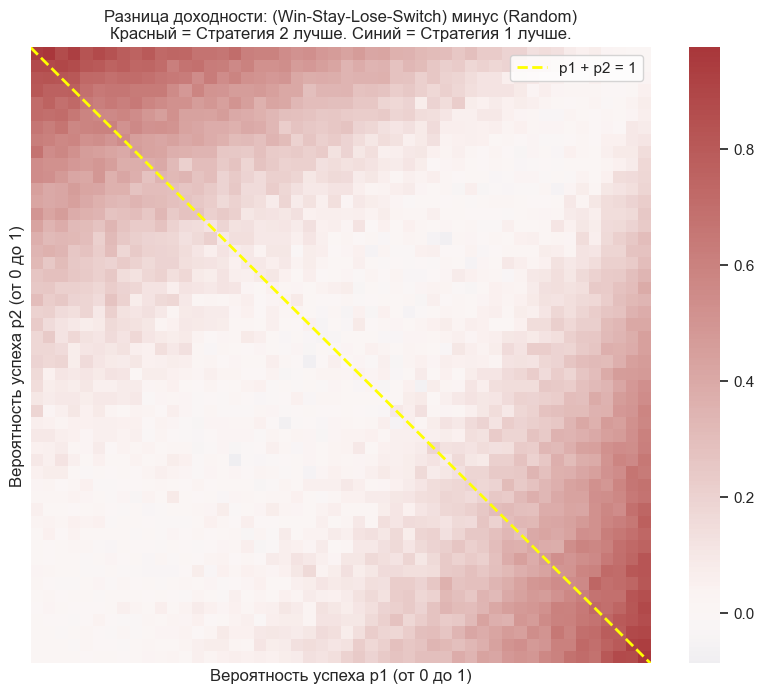

In [12]:

# --- Анализ и Визуализация ---

# Создаем сетку вероятностей от 0.01 до 0.99
resolution = 50
p_values = np.linspace(0.01, 0.99, resolution)
results_matrix = np.zeros((resolution, resolution))

# В теории (для ускорения) мы знаем формулы матожиданий, 
# но здесь запустим честную симуляцию для каждой точки
steps_per_point = 2000 

print("Идет расчет... (может занять пару секунд)")

for i, p1 in enumerate(p_values):
    for j, p2 in enumerate(p_values):
        # Считаем средний выигрыш для обеих стратегий
        avg_1 = run_strategy_1_random(p1, p2, steps_per_point)
        avg_2 = run_strategy_2_wsls(p1, p2, steps_per_point)
        
        # Записываем РАЗНИЦУ (Стратегия 2 - Стратегия 1)
        # Если > 0, то Стратегия 2 лучше. Если < 0, то лучше рандом.
        results_matrix[j, i] = avg_2 - avg_1 

# Рисуем Heatmap
plt.figure(figsize=(10, 8))
# Переворачиваем ось Y, чтобы (0,0) был в углу
sns.heatmap(results_matrix, xticklabels=False, yticklabels=False, center=0, cmap="vlag")

# Подписи осей вручную (примерно)
plt.xlabel("Вероятность успеха p1 (от 0 до 1)")
plt.ylabel("Вероятность успеха p2 (от 0 до 1)")
plt.title("Разница доходности: (Win-Stay-Lose-Switch) минус (Random)\nКрасный = Стратегия 2 лучше. Синий = Стратегия 1 лучше.")
plt.gca().invert_yaxis() # Чтобы 0 был снизу

# Добавляем линию p1 + p2 = 1 (теоретическая граница)
x_line = np.linspace(0, resolution, 100)
y_line = resolution - x_line # Уравнение y = -x + const в координатах матрицы
plt.plot(x_line, y_line, color='yellow', linestyle='--', linewidth=2, label='p1 + p2 = 1')
plt.legend()

plt.show()

Расчет данных...
[8/8] Расчет Random...
[8/8] Расчет Win-Stay Lose-Switch...
[8/8] Расчет Epsilon-Greedy (0.1)...
[8/8] Расчет Decaying Epsilon...
[8/8] Расчет Softmax (temp=0.1)...
[8/8] Расчет Optimistic Greedy...
[8/8] Расчет UCB1...
[8/8] Расчет Thompson Sampling...


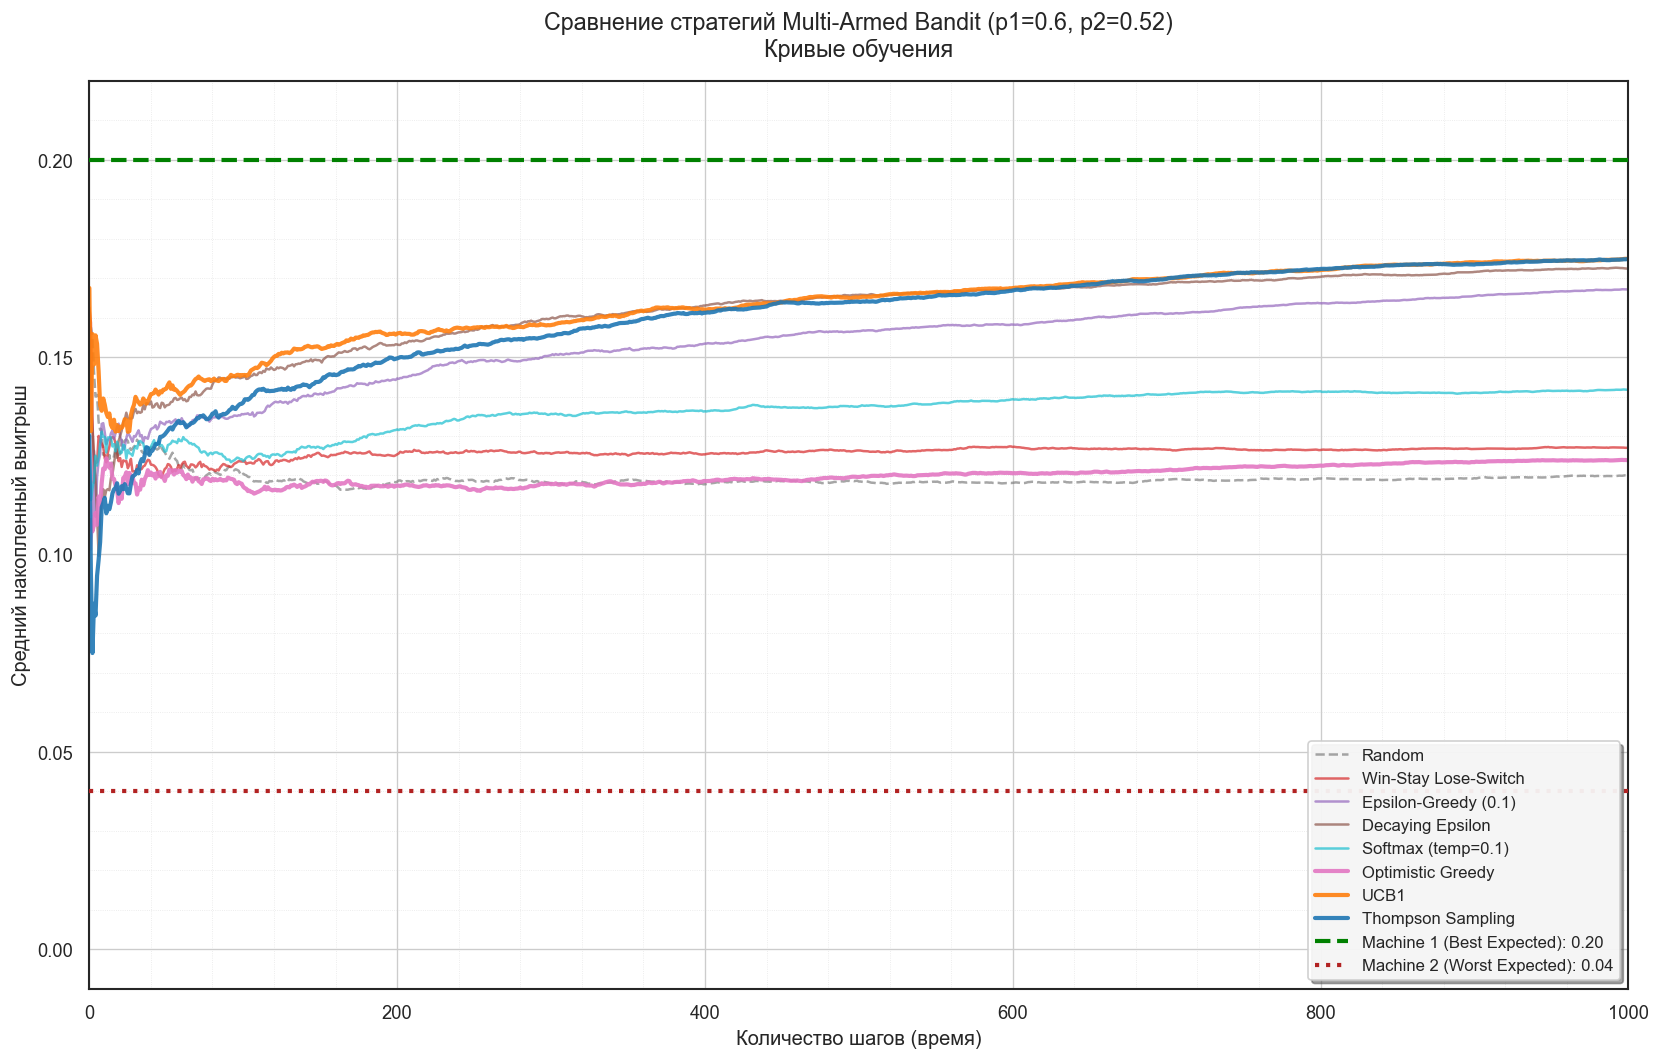

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator

# --- БЛОК СИМУЛЯЦИИ (Тот же, что и раньше) ---
class BanditSimulation:
    def __init__(self, p1, p2):
        self.p = [p1, p2]
        self.expected_rewards = [2 * p - 1 for p in self.p]
        self.max_expected_reward = max(self.expected_rewards)

    def get_reward(self, arm_index):
        return 1 if np.random.rand() < self.p[arm_index] else -1

    def strategy_random(self, steps):
        rewards = np.zeros(steps)
        for t in range(steps):
            rewards[t] = self.get_reward(np.random.randint(0, 2))
        return rewards

    def strategy_wsls(self, steps):
        rewards = np.zeros(steps)
        current_arm = np.random.randint(0, 2)
        for t in range(steps):
            reward = self.get_reward(current_arm)
            rewards[t] = reward
            if reward == -1: current_arm = 1 - current_arm
        return rewards

    def strategy_epsilon_greedy(self, steps, epsilon=0.1):
        rewards = np.zeros(steps)
        stats = np.zeros((2, 2)) 
        for t in range(steps):
            if np.random.rand() < epsilon: arm = np.random.randint(0, 2)
            else:
                means = np.divide(stats[:, 0], stats[:, 1], out=np.zeros(2), where=stats[:, 1]!=0)
                best = np.flatnonzero(means == means.max())
                arm = np.random.choice(best)
            reward = self.get_reward(arm)
            rewards[t] = reward
            stats[arm, 0] += reward; stats[arm, 1] += 1
        return rewards

    def strategy_decaying_epsilon(self, steps):
        rewards = np.zeros(steps)
        stats = np.zeros((2, 2)) 
        for t in range(steps):
            epsilon = 1.0 / (1.0 + t * 0.05) 
            if np.random.rand() < epsilon: arm = np.random.randint(0, 2)
            else:
                means = np.divide(stats[:, 0], stats[:, 1], out=np.zeros(2), where=stats[:, 1]!=0)
                best = np.flatnonzero(means == means.max())
                arm = np.random.choice(best)
            reward = self.get_reward(arm)
            rewards[t] = reward
            stats[arm, 0] += reward; stats[arm, 1] += 1
        return rewards

    def strategy_ucb1(self, steps):
        rewards = np.zeros(steps)
        stats = np.zeros((2, 2))
        for t in range(steps):
            if t < 2: arm = t
            else:
                means = np.divide(stats[:, 0], stats[:, 1], out=np.zeros(2), where=stats[:, 1]!=0)
                bonus = np.sqrt((2 * np.log(t)) / stats[:, 1])
                arm = np.argmax(means + bonus)
            reward = self.get_reward(arm)
            rewards[t] = reward
            stats[arm, 0] += reward; stats[arm, 1] += 1
        return rewards

    def strategy_thompson(self, steps):
        rewards = np.zeros(steps)
        params = np.ones((2, 2))
        for t in range(steps):
            probs = [np.random.beta(params[i, 0], params[i, 1]) for i in range(2)]
            arm = np.argmax(probs)
            reward = self.get_reward(arm)
            rewards[t] = reward
            if reward == 1: params[arm, 0] += 1
            else: params[arm, 1] += 1
        return rewards
    
    def strategy_softmax(self, steps, temperature=0.1):
        rewards = np.zeros(steps)
        stats = np.zeros((2, 2))
        for t in range(steps):
            means = np.divide(stats[:, 0], stats[:, 1], out=np.zeros(2), where=stats[:, 1]!=0)
            exp_v = np.exp(means / temperature)
            probs = exp_v / np.sum(exp_v)
            arm = np.random.choice([0, 1], p=probs)
            reward = self.get_reward(arm)
            rewards[t] = reward
            stats[arm, 0] += reward; stats[arm, 1] += 1
        return rewards

    def strategy_optimistic(self, steps, init_val=500.0):
        rewards = np.zeros(steps)
        stats = np.array([[init_val, 1.0], [init_val, 1.0]])
        for t in range(steps):
            means = stats[:, 0] / stats[:, 1]
            best = np.flatnonzero(means == means.max())
            arm = np.random.choice(best)
            reward = self.get_reward(arm)
            rewards[t] = reward
            stats[arm, 0] += reward; stats[arm, 1] += 1
        return rewards

# --- ПАРАМЕТРЫ ЗАПУСКА ---
P1, P2 = 0.60, 0.52
STEPS = 1000
RUNS = 800

sim = BanditSimulation(P1, P2)
strategies = {
    "Random": sim.strategy_random,
    "Win-Stay Lose-Switch": sim.strategy_wsls,
    "Epsilon-Greedy (0.1)": sim.strategy_epsilon_greedy,
    "Decaying Epsilon": sim.strategy_decaying_epsilon,
    "Softmax (temp=0.1)": sim.strategy_softmax,
    "Optimistic Greedy": sim.strategy_optimistic,
    "UCB1": sim.strategy_ucb1,
    "Thompson Sampling": sim.strategy_thompson
}

print("Расчет данных...")
results = {}
for name, func in strategies.items():
    print(f"[{i+1}/{len(strategies)}] Расчет {name}...")
    all_runs = np.zeros((RUNS, STEPS))
    for r in range(RUNS):
        
        all_runs[r] = func(STEPS)
    results[name] = np.mean(np.cumsum(all_runs, axis=1) / np.arange(1, STEPS + 1), axis=0)

# --- УЛУЧШЕННАЯ ВИЗУАЛИЗАЦИЯ ---

# 1. Настройка стиля (белый фон для контраста)
sns.set_style("white") 
plt.figure(figsize=(14, 9), dpi=120) # Высокое разрешение

# 2. Цветовая палитра (Контрастная 'tab10')
# Можно назначить цвета вручную для лучшей читаемости
colors = {
    "Random": "gray",
    "Win-Stay Lose-Switch": "#d62728", # Красный (tab:red)
    "Epsilon-Greedy (0.1)": "#9467bd", # Фиолетовый (tab:purple)
    "Decaying Epsilon": "#8c564b",     # Коричневый (tab:brown)
    "Softmax (temp=0.1)": "#17becf",   # Циан
    "Optimistic Greedy": "#e377c2",    # Розовый
    "UCB1": "#ff7f0e",                 # Оранжевый (tab:orange)
    "Thompson Sampling": "#1f77b4"     # Синий (tab:blue) - Обычно победитель
}

# 3. Отрисовка линий стратегий
for name, data in results.items():
    # Выделяем лидеров толщиной
    is_leader = "Thompson" in name or "UCB" in name or "Optimistic" in name
    lw = 2.5 if is_leader else 1.5
    # Random делаем пунктиром
    ls = '--' if "Random" in name else '-'
    alpha = 0.9 if is_leader else 0.7
    
    color = colors.get(name, "black")
    
    plt.plot(data, label=name, linewidth=lw, linestyle=ls, color=color, alpha=alpha)

# 4. Линии теоретических пределов (Жирные и четкие)
plt.axhline(y=sim.expected_rewards[0], color='green', linestyle='--', linewidth=2.5, 
            label=f'Machine 1 (Best Expected): {sim.expected_rewards[0]:.2f}', zorder=5)

plt.axhline(y=sim.expected_rewards[1], color='firebrick', linestyle=':', linewidth=2.5, 
            label=f'Machine 2 (Worst Expected): {sim.expected_rewards[1]:.2f}', zorder=5)

# 5. Настройка сетки (Мелкая и полупрозрачная)
ax = plt.gca()
# Включаем мелкие деления
ax.xaxis.set_minor_locator(AutoMinorLocator(5)) # 5 делений между основными
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

# Основная сетка (потемнее)
plt.grid(which='major', color='#CCCCCC', linestyle='-', linewidth=0.8, alpha=1.0)
# Мелкая сетка (посветлее и прозрачнее)
plt.grid(which='minor', color='#DDDDDD', linestyle=':', linewidth=0.5, alpha=0.7)

# 6. Подписи и Легенда
plt.title(f'Сравнение стратегий Multi-Armed Bandit (p1={P1}, p2={P2})\nКривые обучения', fontsize=14, pad=15)
plt.xlabel('Количество шагов (время)', fontsize=12)
plt.ylabel('Средний накопленный выигрыш', fontsize=12)

# Легенда с полупрозрачным фоном
plt.legend(loc='lower right', frameon=True, fancybox=True, framealpha=0.9, fontsize=10, shadow=True)

# Масштабирование
plt.xlim(0, STEPS)
# Фокус на интересной зоне (чуть ниже худшего и чуть выше лучшего)
y_min = min(sim.expected_rewards) - 0.05
y_max = max(sim.expected_rewards) + 0.02
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()